<a href="https://colab.research.google.com/github/MaVee06/Exam/blob/main/22405062_A_Vilakazi_Elections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Vilakazi

22405062


Datasets are both from the same site IEC Results
https://results.elections.org.za/home/Downloads/ME-Results

**PROBLEM STATEMENT**

The 2026 South African Local Government Election provides an opportunity to use the historical data to understand voting patterns so i can develop evidence based predictions

This project focuses on the eThekwini Metropolitan municipality in KZN. The dataset contains historical ward level election results from 2016 and 2021 previous local government elections, including information such as wards, voting districts, registered voters, political parties, vaild and spolit votes.
the project will specifically estimate which party is projected to receive thelargest aggregate vote total, which party is projected to lead in each of the three selected wards also projecting the vote total and voter turnout.


**Importing and loading dataset**

**Data Understanding**
(inspecting my files before we start with the cleaning).

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_2016=pd.read_csv("/content/drive/MyDrive/ETH_Ward (2).csv")
df_2021=pd.read_csv("/content/drive/MyDrive/ETH_Ward (1).csv")

**Checking the shape**

In [3]:
print("2016 dataset shape:",df_2016.shape)
print("2021 dataset shape:",df_2021.shape)

2016 dataset shape: (40706, 11)
2021 dataset shape: (32990, 11)


**Showing column names**

In [4]:
print("2016 columns:")
print(df_2016.columns.tolist())
print("2021 columns:")
print(df_2021.columns.tolist())

2016 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']
2021 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


**Checking the first 5 rows for both datasets**

In [5]:
print("2016 first 5 rows:")
print(df_2016.head())
print("2021 first 5 rows:")
print(df_2021.head())

2016 first 5 rows:
        Province     Municipality           Ward  VotingDistrict  \
0  KwaZulu-Natal  ETH - eThekwini  Ward 59500001        43400179   
1  KwaZulu-Natal  ETH - eThekwini  Ward 59500001        43400179   
2  KwaZulu-Natal  ETH - eThekwini  Ward 59500001        43400179   
3  KwaZulu-Natal  ETH - eThekwini  Ward 59500001        43400179   
4  KwaZulu-Natal  ETH - eThekwini  Ward 59500001        43400179   

           VotingStationName  RegisteredVoters BallotType  SpoiltVotes  \
0  NOMFIHLELA PRIMARY SCHOOL              1607         PR           72   
1  NOMFIHLELA PRIMARY SCHOOL              1607         PR           72   
2  NOMFIHLELA PRIMARY SCHOOL              1607         PR           72   
3  NOMFIHLELA PRIMARY SCHOOL              1607         PR           72   
4  NOMFIHLELA PRIMARY SCHOOL              1607         PR           72   

                            PartyName  TotalValidVotes         DateGenerated  
0             ACADEMIC CONGRESS UNION           

**Checking Data Type**

In [6]:
print("2016data types:")
print(df_2016.dtypes)
print("\n2021 data types:")
print(df_2021.dtypes)

2016data types:
Province             object
Municipality         object
Ward                 object
VotingDistrict        int64
VotingStationName    object
RegisteredVoters      int64
BallotType           object
SpoiltVotes           int64
PartyName            object
TotalValidVotes       int64
DateGenerated        object
dtype: object

2021 data types:
Province             object
Municipality         object
Ward                 object
VotingDistrict        int64
VotingStationName    object
RegisteredVoters      int64
BallotType           object
SpoiltVotes           int64
PartyName            object
TotalValidVotes       int64
DateGenerated        object
dtype: object


**Checking the municipalities**

In [7]:
print("2016 municipalities:")
print(df_2016["Municipality"].unique())
print("\n2021 municipalities:")
print(df_2021["Municipality"].unique())


2016 municipalities:
['ETH - eThekwini']

2021 municipalities:
['ETH - eThekwini']


**Checking the Ballot type**

In [8]:
print("2016 ballot types:")
print(df_2016["BallotType"].value_counts())
print("\n2021 ballot types:")
print(df_2021["BallotType"].value_counts())

2016 ballot types:
BallotType
PR      23382
Ward    17324
Name: count, dtype: int64

2021 ballot types:
BallotType
Ward    32990
Name: count, dtype: int64


**Checking the number of Wards we have**

In [9]:
print("Number of wards in 2016:", df_2016["Ward"].nunique())
print("Number of wards in 2021:", df_2021["Ward"].nunique())

Number of wards in 2016: 110
Number of wards in 2021: 111


**Checking the number of Parties **

In [11]:
print("Number of parties in 2016:", df_2016["PartyName"].nunique())
print("Number of parties in 2021:", df_2021["PartyName"].nunique())

# error was because i had input the incorrect column name

Number of parties in 2016: 28
Number of parties in 2021: 53


Registered voters

In [12]:
print("2016 registered voters:")
print(df_2016["RegisteredVoters"].describe())
print("\n2021 registered voters:")
print(df_2021["RegisteredVoters"].describe())

2016 registered voters:
count    40706.000000
mean      2218.242618
std       1216.222531
min        101.000000
25%       1376.000000
50%       2098.000000
75%       2827.000000
max       8099.000000
Name: RegisteredVoters, dtype: float64

2021 registered voters:
count    32990.000000
mean      2185.880115
std       1189.342444
min        107.000000
25%       1363.000000
50%       2057.000000
75%       2823.000000
max       7910.000000
Name: RegisteredVoters, dtype: float64


**Total number of votes**

In [13]:
print("2016 total votes:")
print(df_2016["TotalValidVotes"].sum())
print("\n2021 total votes:")
print(df_2021["TotalValidVotes"].sum())

2016 total votes:
2225605

2021 total votes:
776015


Understanding of the Dataset is
District: eThekwini municipality in KZN, data from 2016 and 2021 to predict 2026 elections. Only used voting district/ward

**DATA CLEANING**

Here i will be checking if are there any duplicates, missing values, removing unnessary columns and rows before transforming and anaysing the data

In [15]:
clean_2016=df_2016.copy()
clean_2021=df_2021.copy()

print("Copies created successfully.")
print("2016:",clean_2016.shape)
print("2021:",clean_2021.shape)

Copies created successfully.
2016: (40706, 11)
2021: (32990, 11)


In [16]:
clean_2016.columns=(
    clean_2016.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)

clean_2021.columns=(
    clean_2021.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
)
print("2016 columns:")
print(clean_2016.columns.tolist())
print("\n2021 columns:")
print(clean_2021.columns.tolist())


2016 columns:
['province', 'municipality', 'ward', 'votingdistrict', 'votingstationname', 'registeredvoters', 'ballottype', 'spoiltvotes', 'partyname', 'totalvalidvotes', 'dategenerated']

2021 columns:
['province', 'municipality', 'ward', 'votingdistrict', 'votingstationname', 'registeredvoters', 'ballottype', 'spoiltvotes', 'partyname', 'totalvalidvotes', 'dategenerated']


**Checking for missing Values**

In [17]:
print("Missing values in 2016:")
print(clean_2016.isnull().sum())
print("\nMissing values in 2021:")
print(clean_2021.isnull().sum())

Missing values in 2016:
province             0
municipality         0
ward                 0
votingdistrict       0
votingstationname    0
registeredvoters     0
ballottype           0
spoiltvotes          0
partyname            0
totalvalidvotes      0
dategenerated        0
dtype: int64

Missing values in 2021:
province             0
municipality         0
ward                 0
votingdistrict       0
votingstationname    0
registeredvoters     0
ballottype           0
spoiltvotes          0
partyname            0
totalvalidvotes      0
dategenerated        0
dtype: int64


Checking for Dulicates

In [18]:
print("Duplicate rows in 2016:",clean_2016.duplicated().sum())
print("Duplicate rows in 2021:",clean_2021.duplicated().sum())
#

Duplicate rows in 2016: 0
Duplicate rows in 2021: 0


**Checking party names**

In [20]:
print("2016 parties:")
print(clean_2016["partyname"].unique())
print("\nNumber of 2016 parties:", clean_2016["partyname"].nunique())
print("\n2021 parties:")
print(clean_2021["partyname"].unique())
print("\nNumber of 2021 parties:", clean_2021["partyname"].nunique())

2016 parties:
['ACADEMIC CONGRESS UNION' 'AFRICAN CHRISTIAN DEMOCRATIC PARTY'
 'AFRICAN INDEPENDENT CONGRESS' 'AFRICAN MANTUNGWA COMMUNITY'
 'AFRICAN NATIONAL CONGRESS' "AFRICAN PEOPLE'S CONVENTION" 'AL JAMA-AH'
 'ALLIED MOVEMENT FOR CHANGE' "AZANIAN PEOPLE'S ORGANISATION"
 'CONGRESS  OF THE PEOPLE' 'DEMOCRATIC ALLIANCE'
 'DEMOCRATIC LIBERAL CONGRESS' 'ECONOMIC FREEDOM FIGHTERS'
 "INDEPENDENT PEOPLE'S PARTY" 'INDEPENDENT RATEPAYERS ASSOCIATION OF SA'
 'INKATHA FREEDOM PARTY' 'MINORITIES OF SOUTH AFRICA' 'MINORITY FRONT'
 'PAN AFRICANIST CONGRESS OF AZANIA' "PEOPLE'S REVOLUTIONARY MOVEMENT"
 'SOUTH AFRICAN POLITICAL PARTY' 'THE PROMISE OF FREEDOM' 'TRULY ALLIANCE'
 'UNITED DEMOCRATIC MOVEMENT' 'UNITED PEOPLES PARTY'
 'UNITED RESIDENTS FRONT' 'VRYHEIDSFRONT PLUS' 'INDEPENDENT']

Number of 2016 parties: 28

2021 parties:
['ABANTU BATHO CONGRESS' 'ACADEMIC CONGRESS UNION' 'ACTIONSA'
 'ACTIVISTS MOVEMENT OF SOUTH AFRICA' 'ADVANCED DYNAMIC ALLIANCE'
 'AFRICA RESTORATION ALLIANCE' 'AFRICAN CH

converting numerical columns

In [23]:
numeric_columns =[
    "votingdistrict",
    "registeredvoters",
    "spoiltvotes",
    "totalvalidvotes"
]
for column in numeric_columns:
  clean_2016[column]= pd.to_numeric(
      clean_2016[column],
      errors="coerce"
  )
  clean_2021[column]= pd.to_numeric(
      clean_2021[column],
      errors="coerce"
  )
  print("Numeric columns converted successfully.")

Numeric columns converted successfully.
Numeric columns converted successfully.
Numeric columns converted successfully.
Numeric columns converted successfully.


Checking if the conversion didn't creat missing values

In [24]:
print("2016 numeric missing values:")
print(clean_2016[numeric_columns].isnull().sum())
print("\n2021 numeric missing values:")
print(clean_2021[numeric_columns].isnull().sum())


2016 numeric missing values:
votingdistrict      0
registeredvoters    0
spoiltvotes         0
totalvalidvotes     0
dtype: int64

2021 numeric missing values:
votingdistrict      0
registeredvoters    0
spoiltvotes         0
totalvalidvotes     0
dtype: int64


checking for negative values

In [25]:
print("20116 negative values:")
print((clean_2016[numeric_columns]<0).sum())
print("\n2021 negative values:")
print((clean_2021[numeric_columns]<0).sum())


20116 negative values:
votingdistrict      0
registeredvoters    0
spoiltvotes         0
totalvalidvotes     0
dtype: int64

2021 negative values:
votingdistrict      0
registeredvoters    0
spoiltvotes         0
totalvalidvotes     0
dtype: int64


Convert the election date

extracting the election year

In [26]:
print(clean_2016["dategenerated"].head())
print(clean_2021["dategenerated"].head())

0    8/11/2016 3:58:48 PM
1    8/11/2016 3:58:48 PM
2    8/11/2016 3:58:48 PM
3    8/11/2016 3:58:48 PM
4    8/11/2016 3:58:48 PM
Name: dategenerated, dtype: object
0    11/23/2021 4:11:07 PM
1    11/23/2021 4:11:07 PM
2    11/23/2021 4:11:07 PM
3    11/23/2021 4:11:07 PM
4    11/23/2021 4:11:07 PM
Name: dategenerated, dtype: object


In [27]:
clean_2016["dategenerated"]= pd.to_datetime(
    clean_2016["dategenerated"],
    errors="coerce"
)
clean_2021["dategenerated"]= pd.to_datetime(
    clean_2021["dategenerated"],
    errors="coerce"
)
print("Dates converted successfully.")

Dates converted successfully.


In [28]:
print(clean_2016["dategenerated"].dtype)
print(clean_2021["dategenerated"].dtype)

datetime64[ns]
datetime64[ns]


In [29]:
clean_2016["election_year"]=clean_2016["dategenerated"].dt.year
clean_2021["election_year"]=clean_2021["dategenerated"].dt.year

print(clean_2016["election_year"].unique())
print(clean_2021["election_year"].unique())

[2016]
[2021]


Keeping only ward results

In [30]:
clean_2016_ward=clean_2016[
    clean_2016["ballottype"]=="Ward"
].copy()
clean_2021_ward=clean_2021[
    clean_2021["ballottype"]=="Ward"
].copy()
print("2016 ward data:", clean_2016_ward.shape)
print("2021 ward data:", clean_2021_ward.shape)

2016 ward data: (17324, 12)
2021 ward data: (32990, 12)


Checking Ward Names and changed wards or added

In [31]:
print("2016 wards:")
print(sorted(clean_2016_ward["ward"].unique())[:20])
print("\n2021 wards:")
print(sorted(clean_2021_ward["ward"].unique())[:20])

2016 wards:
['Ward 59500001', 'Ward 59500002', 'Ward 59500003', 'Ward 59500004', 'Ward 59500005', 'Ward 59500006', 'Ward 59500007', 'Ward 59500008', 'Ward 59500009', 'Ward 59500010', 'Ward 59500011', 'Ward 59500012', 'Ward 59500013', 'Ward 59500014', 'Ward 59500015', 'Ward 59500016', 'Ward 59500017', 'Ward 59500018', 'Ward 59500019', 'Ward 59500020']

2021 wards:
['Ward 59500001', 'Ward 59500002', 'Ward 59500003', 'Ward 59500004', 'Ward 59500005', 'Ward 59500006', 'Ward 59500007', 'Ward 59500008', 'Ward 59500009', 'Ward 59500010', 'Ward 59500011', 'Ward 59500012', 'Ward 59500013', 'Ward 59500014', 'Ward 59500015', 'Ward 59500016', 'Ward 59500017', 'Ward 59500018', 'Ward 59500019', 'Ward 59500020']


In [32]:
wards_2016= set(clean_2016_ward["ward"].unique())
wards_2021= set(clean_2021_ward["ward"].unique())
print("Wards only in 2016:")
print(sorted(wards_2016 - wards_2021))
print("\nWards only in 2021:")
print(sorted(wards_2021 - wards_2016))

Wards only in 2016:
[]

Wards only in 2021:
['Ward 59500111']


saving the cleaned dataset

In [34]:
clean_2016_ward.to_csv(
    "eThekwini_2016_ward.csv",
    index=False
)
clean_2021_ward.to_csv(
    "eThekwini_2021_ward.csv",
    index=False
)
print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.


**DATA TRANSFORMATION**

Here i will turn the cleanedrecords into a structure that we can use for the 2026 analysis

In [36]:
print("2016 Ward records:", len(clean_2016_ward))
print("2021 Ward records:", len(clean_2021_ward))

2016 Ward records: 17324
2021 Ward records: 32990


In [38]:
clean_2016_ward[
    clean_2016_ward["ward"] == clean_2016_ward["ward"].iloc[0]
].head(10)


,province,municipality,ward,votingdistrict,votingstationname,registeredvoters,ballottype,spoiltvotes,partyname,totalvalidvotes,dategenerated,election_year
27,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,ACADEMIC CONGRESS UNION,0,2016-08-11 15:58:48,2016
28,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,2016-08-11 15:58:48,2016
29,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,AFRICAN INDEPENDENT CONGRESS,28,2016-08-11 15:58:48,2016
30,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,AFRICAN NATIONAL CONGRESS,1000,2016-08-11 15:58:48,2016
31,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,AFRICAN PEOPLE'S CONVENTION,3,2016-08-11 15:58:48,2016
32,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,AL JAMA-AH,0,2016-08-11 15:58:48,2016
33,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,AZANIAN PEOPLE'S ORGANISATION,0,2016-08-11 15:58:48,2016
34,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,DEMOCRATIC ALLIANCE,4,2016-08-11 15:58:48,2016
35,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,DEMOCRATIC LIBERAL CONGRESS,2,2016-08-11 15:58:48,2016
36,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,Ward,11,ECONOMIC FREEDOM FIGHTERS,2,2016-08-11 15:58:48,2016


In [39]:
clean_2021_ward[
    clean_2021_ward["ward"] == clean_2021_ward["ward"].iloc[0]
].head(10)


,province,municipality,ward,votingdistrict,votingstationname,registeredvoters,ballottype,spoiltvotes,partyname,totalvalidvotes,dategenerated,election_year
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ABANTU BATHO CONGRESS,19,2021-11-23 16:11:07,2021
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACADEMIC CONGRESS UNION,0,2021-11-23 16:11:07,2021
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIONSA,0,2021-11-23 16:11:07,2021
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0,2021-11-23 16:11:07,2021
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,ADVANCED DYNAMIC ALLIANCE,0,2021-11-23 16:11:07,2021
5,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,AFRICA RESTORATION ALLIANCE,1,2021-11-23 16:11:07,2021
6,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,2021-11-23 16:11:07,2021
7,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,AFRICAN DEMOCRATIC CHANGE,0,2021-11-23 16:11:07,2021
8,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,AFRICAN MANTUNGWA COMMUNITY,4,2021-11-23 16:11:07,2021
9,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,Ward,8,AFRICAN NATIONAL CONGRESS,860,2021-11-23 16:11:07,2021


calculating the party totals by ward

In [41]:
ward_party_2016 =(
    clean_2016_ward
    .groupby(
        ["ward","partyname"],
        as_index=False
        )["totalvalidvotes"]
    .sum()
)
print(ward_party_2016.head())

            ward                           partyname  totalvalidvotes
0  Ward 59500001             ACADEMIC CONGRESS UNION                1
1  Ward 59500001  AFRICAN CHRISTIAN DEMOCRATIC PARTY                8
2  Ward 59500001        AFRICAN INDEPENDENT CONGRESS              217
3  Ward 59500001           AFRICAN NATIONAL CONGRESS             9773
4  Ward 59500001         AFRICAN PEOPLE'S CONVENTION                9


In [42]:
ward_party_2021 =(
    clean_2021_ward
    .groupby(
        ["ward","partyname"],
        as_index=False
        )["totalvalidvotes"]
    .sum()
)
print(ward_party_2021.head())

            ward                           partyname  totalvalidvotes
0  Ward 59500001               ABANTU BATHO CONGRESS              304
1  Ward 59500001             ACADEMIC CONGRESS UNION                3
2  Ward 59500001                            ACTIONSA               16
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA                2
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE                3


checking the number of ward party combinations

In [43]:
print(
    "2016 ward-party combinations:",
    len(ward_party_2016)
)
print(
    "2021 ward-party combinations:",
    len(ward_party_2021)
)

2016 ward-party combinations: 2206
2021 ward-party combinations: 4191


Calculating total votes per ward and also party vote share

In [50]:
ward_totals_2016=(
    ward_party_2016
    .groupby("ward",as_index=False)["totalvalidvotes"]
    .sum()
    .rename(
        columns={
            "totalvalidvotes": "ward_total_votes"
        }
    )
)
print(ward_totals_2016.head())

            ward  ward_total_votes
0  Ward 59500001             12679
1  Ward 59500002             10087
2  Ward 59500003              9609
3  Ward 59500004             12565
4  Ward 59500005              9914


In [49]:
ward_totals_2021=(
    ward_party_2021
    .groupby("ward",as_index=False)["totalvalidvotes"]
    .sum()
    .rename(
        columns={
            "totalvalidvotes": "ward_total_votes"
        }
    )
)
print(ward_totals_2021.head())


            ward  ward_total_votes
0  Ward 59500001             10381
1  Ward 59500002              8836
2  Ward 59500003              6462
3  Ward 59500004              8560
4  Ward 59500005              6359


In [54]:
ward_party_2016= ward_party_2016.drop(
    columns=[
        "ward_total_votes",
        "ward_total_votes_x",
        "ward_total_votes_y"
    ],
    errors="ignore"
)
ward_party_2016 = ward_party_2016.merge(
    ward_totals_2016,
    on="ward",
    how="left"
)
print(ward_party_2016.head())
print(ward_party_2016.columns.tolist())

            ward                           partyname  totalvalidvotes  \
0  Ward 59500001             ACADEMIC CONGRESS UNION                1   
1  Ward 59500001  AFRICAN CHRISTIAN DEMOCRATIC PARTY                8   
2  Ward 59500001        AFRICAN INDEPENDENT CONGRESS              217   
3  Ward 59500001           AFRICAN NATIONAL CONGRESS             9773   
4  Ward 59500001         AFRICAN PEOPLE'S CONVENTION                9   

   vote_share  ward_total_votes  
0    0.007887             12679  
1    0.063096             12679  
2    1.711491             12679  
3   77.080211             12679  
4    0.070984             12679  
['ward', 'partyname', 'totalvalidvotes', 'vote_share', 'ward_total_votes']


In [55]:

ward_party_2016["vote_share"]= (
    ward_party_2016["totalvalidvotes"]
    / ward_party_2016["ward_total_votes"]
)*100
print(ward_party_2016.head())

            ward                           partyname  totalvalidvotes  \
0  Ward 59500001             ACADEMIC CONGRESS UNION                1   
1  Ward 59500001  AFRICAN CHRISTIAN DEMOCRATIC PARTY                8   
2  Ward 59500001        AFRICAN INDEPENDENT CONGRESS              217   
3  Ward 59500001           AFRICAN NATIONAL CONGRESS             9773   
4  Ward 59500001         AFRICAN PEOPLE'S CONVENTION                9   

   vote_share  ward_total_votes  
0    0.007887             12679  
1    0.063096             12679  
2    1.711491             12679  
3   77.080211             12679  
4    0.070984             12679  


In [56]:
ward_party_2016= ward_party_2021.drop(
    columns=[
        "ward_total_votes",
        "ward_total_votes_x",
        "ward_total_votes_y"
    ],
    errors="ignore"
)
ward_party_2021 = ward_party_2021.merge(
    ward_totals_2021,
    on="ward",
    how="left"
)
print(ward_party_2021.head())
print(ward_party_2021.columns.tolist())

            ward                           partyname  totalvalidvotes  \
0  Ward 59500001               ABANTU BATHO CONGRESS              304   
1  Ward 59500001             ACADEMIC CONGRESS UNION                3   
2  Ward 59500001                            ACTIONSA               16   
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA                2   
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE                3   

   ward_total_votes  
0             10381  
1             10381  
2             10381  
3             10381  
4             10381  
['ward', 'partyname', 'totalvalidvotes', 'ward_total_votes']


In [57]:
ward_party_2021["vote_share"]= (
    ward_party_2021["totalvalidvotes"]
    / ward_party_2021["ward_total_votes"]
)*100
print(ward_party_2021.head())

            ward                           partyname  totalvalidvotes  \
0  Ward 59500001               ABANTU BATHO CONGRESS              304   
1  Ward 59500001             ACADEMIC CONGRESS UNION                3   
2  Ward 59500001                            ACTIONSA               16   
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA                2   
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE                3   

   ward_total_votes  vote_share  
0             10381    2.928427  
1             10381    0.028899  
2             10381    0.154128  
3             10381    0.019266  
4             10381    0.028899  


Calculating wide party total

In [60]:
from itertools import groupby
party_totals_2016 = (
    ward_party_2016
    .groupby("partyname")["totalvalidvotes"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "totalvalidvotes": "party_total_votes"
        }
    )
)
print(
    party_totals_2016
    .sort_values("party_total_votes",ascending=False)
    .head(10)
)


                             partyname  party_total_votes
13           AFRICAN NATIONAL CONGRESS             324137
24                 DEMOCRATIC ALLIANCE             198433
27           ECONOMIC FREEDOM FIGHTERS              78748
34               INKATHA FREEDOM PARTY              51725
32                         INDEPENDENT              32987
2                             ACTIONSA              11663
3            ACTIVE CITIZENS COALITION               8025
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY               6022
0                ABANTU BATHO CONGRESS               5866
17     AFRICAN TRANSFORMATION MOVEMENT               5131


In [59]:
print(party_totals_2016.columns.tolist())
print(party_totals_2016.head())

['partyname', 'party_total_votes']
                            partyname  party_total_votes
0               ABANTU BATHO CONGRESS               5866
1             ACADEMIC CONGRESS UNION                289
2                            ACTIONSA              11663
3           ACTIVE CITIZENS COALITION               8025
4  ACTIVISTS MOVEMENT OF SOUTH AFRICA                917


In [65]:
ward_party_2021 =(
    clean_2021_ward
    .groupby(
        ["ward","partyname"],
        as_index=False
    )["totalvalidvotes"]
    .sum()
)
print(ward_party_2021.head())
print(ward_party_2021.shape)

            ward                           partyname  totalvalidvotes
0  Ward 59500001               ABANTU BATHO CONGRESS              304
1  Ward 59500001             ACADEMIC CONGRESS UNION                3
2  Ward 59500001                            ACTIONSA               16
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA                2
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE                3
(4191, 3)


In [67]:
ward_totals_2021 = (
    ward_party_2021
    .groupby("ward", as_index=False)["totalvalidvotes"]
    .sum()
    .rename(columns={
        "totalvalidvotes": "ward_total_votes"
    })
)

print(ward_totals_2021.head())
print(ward_totals_2021.shape)

            ward  ward_total_votes
0  Ward 59500001             10381
1  Ward 59500002              8836
2  Ward 59500003              6462
3  Ward 59500004              8560
4  Ward 59500005              6359
(111, 2)


In [66]:
party_totals_2021 =(
    ward_party_2021
    .groupby("partyname", as_index=False)["totalvalidvotes"]
    .sum()
)
party_totals_2021= party_totals_2021.rename(
        columns={
            "totalvalidvotes": "party_total_votes_2021"
        }
)

party_totals_2021 =(
        party_totals_2021
        .sort_values("party_total_votes_2021",ascending=False)
        .reset_index(drop=True)
)
print(party_totals_2021.head(10))


                            partyname  party_total_votes_2021
0           AFRICAN NATIONAL CONGRESS                  324137
1                 DEMOCRATIC ALLIANCE                  198433
2           ECONOMIC FREEDOM FIGHTERS                   78748
3               INKATHA FREEDOM PARTY                   51725
4                         INDEPENDENT                   32987
5                            ACTIONSA                   11663
6           ACTIVE CITIZENS COALITION                    8025
7  AFRICAN CHRISTIAN DEMOCRATIC PARTY                    6022
8               ABANTU BATHO CONGRESS                    5866
9     AFRICAN TRANSFORMATION MOVEMENT                    5131


In [68]:
ward_party_2021 = ward_party_2021.merge(
    ward_totals_2021,
    on="ward",
    how="left"
)
print(ward_party_2021.head())
print(ward_party_2021.columns.tolist())

            ward                           partyname  totalvalidvotes  \
0  Ward 59500001               ABANTU BATHO CONGRESS              304   
1  Ward 59500001             ACADEMIC CONGRESS UNION                3   
2  Ward 59500001                            ACTIONSA               16   
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA                2   
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE                3   

   ward_total_votes  
0             10381  
1             10381  
2             10381  
3             10381  
4             10381  
['ward', 'partyname', 'totalvalidvotes', 'ward_total_votes']


In [69]:
ward_party_2021["vote_share_2021"]= (
    ward_party_2021["totalvalidvotes"]
    / ward_party_2021["ward_total_votes"]
)*100
print(ward_party_2021.head())

            ward                           partyname  totalvalidvotes  \
0  Ward 59500001               ABANTU BATHO CONGRESS              304   
1  Ward 59500001             ACADEMIC CONGRESS UNION                3   
2  Ward 59500001                            ACTIONSA               16   
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA                2   
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE                3   

   ward_total_votes  vote_share_2021  
0             10381         2.928427  
1             10381         0.028899  
2             10381         0.154128  
3             10381         0.019266  
4             10381         0.028899  


In [70]:
party_totals_2021 =(
    ward_party_2021
    .groupby("partyname", as_index=False)["totalvalidvotes"]
    .sum()
    .rename(columns={
        "totalvalidvotes": "party_total_votes_2021"
    })
)
party_totals_2021 =(
    party_totals_2021
    .sort_values("party_total_votes_2021",ascending=False)
    .reset_index(drop=True)
)
print(party_totals_2021.head(10))

                            partyname  party_total_votes_2021
0           AFRICAN NATIONAL CONGRESS                  324137
1                 DEMOCRATIC ALLIANCE                  198433
2           ECONOMIC FREEDOM FIGHTERS                   78748
3               INKATHA FREEDOM PARTY                   51725
4                         INDEPENDENT                   32987
5                            ACTIONSA                   11663
6           ACTIVE CITIZENS COALITION                    8025
7  AFRICAN CHRISTIAN DEMOCRATIC PARTY                    6022
8               ABANTU BATHO CONGRESS                    5866
9     AFRICAN TRANSFORMATION MOVEMENT                    5131


In [71]:
print("2021 rows:", len(clean_2021_ward))
print("\nFirst 10 rows:")
print(
    clean_2021_ward[
        ["ward", "partyname", "totalvalidvotes"]
    ].head(10)
)

print("\nNumber of wards:", clean_2021_ward["ward"].nunique())
print("\nNumber of parties:", clean_2021_ward["partyname"].nunique())


2021 rows: 32990

First 10 rows:
            ward                           partyname  totalvalidvotes
0  Ward 59500001               ABANTU BATHO CONGRESS               19
1  Ward 59500001             ACADEMIC CONGRESS UNION                0
2  Ward 59500001                            ACTIONSA                0
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA                0
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE                0
5  Ward 59500001         AFRICA RESTORATION ALLIANCE                1
6  Ward 59500001  AFRICAN CHRISTIAN DEMOCRATIC PARTY                0
7  Ward 59500001           AFRICAN DEMOCRATIC CHANGE                0
8  Ward 59500001         AFRICAN MANTUNGWA COMMUNITY                4
9  Ward 59500001           AFRICAN NATIONAL CONGRESS              860

Number of wards: 111

Number of parties: 53


In [72]:
print("2016 total votes:")
print(clean_2016_ward["totalvalidvotes"].sum())

print("\n2021 total votes:")
print(clean_2021_ward["totalvalidvotes"].sum())

print("\n2021 top 10 parties directly from source data:")
print(
    clean_2021_ward
    .groupby("partyname")["totalvalidvotes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


2016 total votes:
1121053

2021 total votes:
776015

2021 top 10 parties directly from source data:
partyname
AFRICAN NATIONAL CONGRESS             324137
DEMOCRATIC ALLIANCE                   198433
ECONOMIC FREEDOM FIGHTERS              78748
INKATHA FREEDOM PARTY                  51725
INDEPENDENT                            32987
ACTIONSA                               11663
ACTIVE CITIZENS COALITION               8025
AFRICAN CHRISTIAN DEMOCRATIC PARTY      6022
ABANTU BATHO CONGRESS                   5866
AFRICAN TRANSFORMATION MOVEMENT         5131
Name: totalvalidvotes, dtype: int64


In [73]:
print("ANC 2016:")
print(
    clean_2016_ward[
        clean_2016_ward["partyname"] == "AFRICAN NATIONAL CONGRESS"
    ]["totalvalidvotes"].sum()
)

print("\nANC 2021:")
print(
    clean_2021_ward[
        clean_2021_ward["partyname"] == "AFRICAN NATIONAL CONGRESS"
    ]["totalvalidvotes"].sum()
)

print("\nDA 2016:")
print(
    clean_2016_ward[
        clean_2016_ward["partyname"] == "DEMOCRATIC ALLIANCE"
    ]["totalvalidvotes"].sum()
)

print("\nDA 2021:")
print(
    clean_2021_ward[
        clean_2021_ward["partyname"] == "DEMOCRATIC ALLIANCE"
    ]["totalvalidvotes"].sum()
)


ANC 2016:
593621

ANC 2021:
324137

DA 2016:
294867

DA 2021:
198433


In [74]:
party_totals_2021 = (
    clean_2021_ward
    .groupby("partyname", as_index=False)["totalvalidvotes"]
    .sum()
    .rename(columns={
        "totalvalidvotes": "party_total_votes"
    })
)

party_totals_2021 = party_totals_2021.sort_values(
    "party_total_votes",
    ascending=False
)

print(party_totals_2021.head(10))


                             partyname  party_total_votes
13           AFRICAN NATIONAL CONGRESS             324137
24                 DEMOCRATIC ALLIANCE             198433
27           ECONOMIC FREEDOM FIGHTERS              78748
34               INKATHA FREEDOM PARTY              51725
32                         INDEPENDENT              32987
2                             ACTIONSA              11663
3            ACTIVE CITIZENS COALITION               8025
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY               6022
0                ABANTU BATHO CONGRESS               5866
17     AFRICAN TRANSFORMATION MOVEMENT               5131


Combining 2016 and 2021 party Totals

In [75]:
party_totals_2016_clean = (
    clean_2016_ward
    .groupby("partyname", as_index=False)["totalvalidvotes"]
    .sum()
    .rename(columns={
        "totalvalidvotes": "votes_2016"
    })
)

party_totals_2021_clean = (
    clean_2021_ward
    .groupby("partyname", as_index=False)["totalvalidvotes"]
    .sum()
    .rename(columns={
        "totalvalidvotes": "votes_2021"
    })
)

party_comparison = party_totals_2016_clean.merge(
    party_totals_2021_clean,
    on="partyname",
    how="outer"
).fillna(0)

print(party_comparison.sort_values(
    "votes_2021",
    ascending=False
).head(15))

                             partyname  votes_2016  votes_2021
13           AFRICAN NATIONAL CONGRESS    593621.0    324137.0
24                 DEMOCRATIC ALLIANCE    294867.0    198433.0
27           ECONOMIC FREEDOM FIGHTERS     36552.0     78748.0
35               INKATHA FREEDOM PARTY     46154.0     51725.0
32                         INDEPENDENT     93432.0     32987.0
2                             ACTIONSA         0.0     11663.0
3            ACTIVE CITIZENS COALITION         0.0      8025.0
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY      6147.0      6022.0
0                ABANTU BATHO CONGRESS         0.0      5866.0
17     AFRICAN TRANSFORMATION MOVEMENT         0.0      5131.0
25         DEMOCRATIC LIBERAL CONGRESS      6714.0      4739.0
8            AFRICAN DEMOCRATIC CHANGE         0.0      4328.0
37        JUSTICE AND EMPLOYMENT PARTY         0.0      3959.0
41                      MINORITY FRONT      6725.0      3661.0
40          MINORITIES OF SOUTH AFRICA      3870.0     

calculating the vote change


In [76]:
party_comparison["vote_change"] = (
    party_comparison["votes_2021"]
    - party_comparison["votes_2016"]
)

party_comparison["percentage_change"] = (
    party_comparison["vote_change"]
    / party_comparison["votes_2016"].replace(0, float("nan"))
) * 100

print(
    party_comparison.sort_values(
        "vote_change",
        ascending=False
    ).head(15)
)

                          partyname  votes_2016  votes_2021  vote_change  \
27        ECONOMIC FREEDOM FIGHTERS     36552.0     78748.0      42196.0   
2                          ACTIONSA         0.0     11663.0      11663.0   
3         ACTIVE CITIZENS COALITION         0.0      8025.0       8025.0   
0             ABANTU BATHO CONGRESS         0.0      5866.0       5866.0   
35            INKATHA FREEDOM PARTY     46154.0     51725.0       5571.0   
17  AFRICAN TRANSFORMATION MOVEMENT         0.0      5131.0       5131.0   
8         AFRICAN DEMOCRATIC CHANGE         0.0      4328.0       4328.0   
37     JUSTICE AND EMPLOYMENT PARTY         0.0      3959.0       3959.0   
55      UNITED INDEPENDENT MOVEMENT         0.0      2919.0       2919.0   
42           NATIONAL FREEDOM PARTY         0.0      2493.0       2493.0   
22           CAPE COLOURED CONGRESS         0.0      2282.0       2282.0   
45           PEOPLE'S FREEDOM PARTY         0.0      2058.0       2058.0   
38          

In [77]:
# Calculate total votes in each election
total_votes_2016 = party_comparison["votes_2016"].sum()
total_votes_2021 = party_comparison["votes_2021"].sum()

# Calculate vote share
party_comparison["share_2016"] = (
    party_comparison["votes_2016"] / total_votes_2016
) * 100

party_comparison["share_2021"] = (
    party_comparison["votes_2021"] / total_votes_2021
) * 100

# Calculate change in vote share
party_comparison["share_change"] = (
    party_comparison["share_2021"]
    - party_comparison["share_2016"]
)

print(
    party_comparison[
        [
            "partyname",
            "votes_2016",
            "votes_2021",
            "share_2016",
            "share_2021",
            "share_change"
        ]
    ]
    .sort_values("share_2021", ascending=False)
    .head(10)
)

                             partyname  votes_2016  votes_2021  share_2016  \
13           AFRICAN NATIONAL CONGRESS    593621.0    324137.0   52.952091   
24                 DEMOCRATIC ALLIANCE    294867.0    198433.0   26.302681   
27           ECONOMIC FREEDOM FIGHTERS     36552.0     78748.0    3.260506   
35               INKATHA FREEDOM PARTY     46154.0     51725.0    4.117022   
32                         INDEPENDENT     93432.0     32987.0    8.334307   
2                             ACTIONSA         0.0     11663.0    0.000000   
3            ACTIVE CITIZENS COALITION         0.0      8025.0    0.000000   
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY      6147.0      6022.0    0.548324   
0                ABANTU BATHO CONGRESS         0.0      5866.0    0.000000   
17     AFRICAN TRANSFORMATION MOVEMENT         0.0      5131.0    0.000000   

    share_2021  share_change  
13   41.769425    -11.182666  
24   25.570769     -0.731913  
27   10.147742      6.887236  
35    6.665464   

**FORCASTING MODEL**



cALCULATING RAW 2026 projection

In [89]:
party_comparison["projected_share_2026_raw"] = (
    party_comparison["votes_2021"]
    + party_comparison["share_change"]
)
print(
    party_comparison[
        [
            "partyname",
            "share_2016",
            "share_2021",
            "share_change",
            "projected_share_2026_raw"
        ]
    ]
    .sort_values("projected_share_2026_raw", ascending=False)
    .head(10)
)

                             partyname  share_2016  share_2021  share_change  \
13           AFRICAN NATIONAL CONGRESS   52.952091   41.769425    -11.182666   
24                 DEMOCRATIC ALLIANCE   26.302681   25.570769     -0.731913   
27           ECONOMIC FREEDOM FIGHTERS    3.260506   10.147742      6.887236   
35               INKATHA FREEDOM PARTY    4.117022    6.665464      2.548442   
32                         INDEPENDENT    8.334307    4.250820     -4.083487   
2                             ACTIONSA    0.000000    1.502935      1.502935   
3            ACTIVE CITIZENS COALITION    0.000000    1.034129      1.034129   
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY    0.548324    0.776016      0.227692   
0                ABANTU BATHO CONGRESS    0.000000    0.755913      0.755913   
17     AFRICAN TRANSFORMATION MOVEMENT    0.000000    0.661199      0.661199   

    projected_share_2026_raw  
13             324125.817334  
24             198432.268087  
27              78754.8872

In [90]:
party_comparison["forecast_2026_share"] = (
    party_comparison["share_2021"]
  + party_comparison["share_change"]
)

print(
    party_comparison[
    [
        "partyname",
        "share_2016",
        "share_2021",
        "share_change",
        "forecast_2026_share"
    ]
    ]
    .sort_values("forecast_2026_share", ascending=False)
    .head(15)
)


                             partyname  share_2016  share_2021  share_change  \
13           AFRICAN NATIONAL CONGRESS   52.952091   41.769425    -11.182666   
24                 DEMOCRATIC ALLIANCE   26.302681   25.570769     -0.731913   
27           ECONOMIC FREEDOM FIGHTERS    3.260506   10.147742      6.887236   
35               INKATHA FREEDOM PARTY    4.117022    6.665464      2.548442   
2                             ACTIONSA    0.000000    1.502935      1.502935   
3            ACTIVE CITIZENS COALITION    0.000000    1.034129      1.034129   
0                ABANTU BATHO CONGRESS    0.000000    0.755913      0.755913   
17     AFRICAN TRANSFORMATION MOVEMENT    0.000000    0.661199      0.661199   
8            AFRICAN DEMOCRATIC CHANGE    0.000000    0.557721      0.557721   
37        JUSTICE AND EMPLOYMENT PARTY    0.000000    0.510171      0.510171   
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY    0.548324    0.776016      0.227692   
55         UNITED INDEPENDENT MOVEMENT  

Check total and negative projection

In [91]:
print("Total projection share:")
print(party_comparison["forecast_2026_share"].sum())

print("\nNegative projections:")
print(
    party_comparison[
        party_comparison["forecast_2026_share"] < 0
    ][
        ["partyname", "forecast_2026_share"]
    ]
)

Total projection share:
99.99999999999999

Negative projections:
                                   partyname  forecast_2026_share
11              AFRICAN INDEPENDENT CONGRESS            -0.577985
23                   CONGRESS  OF THE PEOPLE            -0.016338
34  INDEPENDENT RATEPAYERS ASSOCIATION OF SA            -0.047901
47             SOUTH AFRICAN POLITICAL PARTY            -0.001606
50                    THE PROMISE OF FREEDOM            -0.003122
54                UNITED DEMOCRATIC MOVEMENT            -0.006512
56                      UNITED PEOPLES PARTY            -0.167075
57                    UNITED RESIDENTS FRONT            -0.024084


In [92]:
party_comparison["forecast_2026_clean"] = (
    party_comparison["forecast_2026_share"].clip(lower=0)

)

forecast_total=party_comparison["forecast_2026_clean"].sum()

party_comparison["forecast_2026_final"] = (
    party_comparison["forecast_2026_clean"]
    / forecast_total
) *100

forecast_2026= party_comparison.sort_values(
    "forecast_2026_final",
    ascending=False
)

print(
    forecast_2026[
        [
            "partyname",
            "share_2016",
            "share_2021",
            "forecast_2026_share",
            "forecast_2026_final"
        ]
    ].head(15)
)
print("\nTotal final forecast:")
print(forecast_2026["forecast_2026_final"].sum())

                             partyname  share_2016  share_2021  \
13           AFRICAN NATIONAL CONGRESS   52.952091   41.769425   
24                 DEMOCRATIC ALLIANCE   26.302681   25.570769   
27           ECONOMIC FREEDOM FIGHTERS    3.260506   10.147742   
35               INKATHA FREEDOM PARTY    4.117022    6.665464   
2                             ACTIONSA    0.000000    1.502935   
3            ACTIVE CITIZENS COALITION    0.000000    1.034129   
0                ABANTU BATHO CONGRESS    0.000000    0.755913   
17     AFRICAN TRANSFORMATION MOVEMENT    0.000000    0.661199   
8            AFRICAN DEMOCRATIC CHANGE    0.000000    0.557721   
37        JUSTICE AND EMPLOYMENT PARTY    0.000000    0.510171   
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY    0.548324    0.776016   
55         UNITED INDEPENDENT MOVEMENT    0.000000    0.376153   
42              NATIONAL FREEDOM PARTY    0.000000    0.321257   
25         DEMOCRATIC LIBERAL CONGRESS    0.598901    0.610684   
22        

In [93]:
total_votes_2021= clean_2021_ward["totalvalidvotes"].sum()

forecast_2026["projected_votes_2026"] = (
    forecast_2026["forecast_2026_final"]
    / 100
) * total_votes_2021

forecast_2026["projected_votes_2026"]=(
    forecast_2026["projected_votes_2026"]
    .round()
    .astype(int)
)
print(
    forecast_2026[
        [
        "partyname",
        "forecast_2026_final",
        "projected_votes_2026"
    ]


    ].head(15)
)
print("\nTotal projected votes:")
print(forecast_2026["projected_votes_2026"].sum())

                             partyname  forecast_2026_final  \
13           AFRICAN NATIONAL CONGRESS            30.330579   
24                 DEMOCRATIC ALLIANCE            24.630818   
27           ECONOMIC FREEDOM FIGHTERS            16.892302   
35               INKATHA FREEDOM PARTY             9.136735   
2                             ACTIONSA             2.980694   
3            ACTIVE CITIZENS COALITION             2.050936   
0                ABANTU BATHO CONGRESS             1.499164   
17     AFRICAN TRANSFORMATION MOVEMENT             1.311321   
8            AFRICAN DEMOCRATIC CHANGE             1.106100   
37        JUSTICE AND EMPLOYMENT PARTY             1.011795   
7   AFRICAN CHRISTIAN DEMOCRATIC PARTY             0.995302   
55         UNITED INDEPENDENT MOVEMENT             0.746004   
42              NATIONAL FREEDOM PARTY             0.637132   
25         DEMOCRATIC LIBERAL CONGRESS             0.617253   
22              CAPE COLOURED CONGRESS             0.58

Checking the historical elections

In [94]:
print("2026 total valid votes:", clean_2016_ward["totalvalidvotes"].sum())
print("2021 total valid votes:", clean_2021_ward["totalvalidvotes"].sum())

print("\nNumber of wards:")
print("2016:", clean_2016_ward["ward"].nunique())
print("2021:", clean_2021_ward["ward"].nunique())

print("\nNumber of parties:")
print("2016:", clean_2016_ward["partyname"].nunique())
print("2021:", clean_2021_ward["partyname"].nunique())

2026 total valid votes: 1121053
2021 total valid votes: 776015

Number of wards:
2016: 110
2021: 111

Number of parties:
2016: 28
2021: 53


**EVALUATING THE MODEL**

In [95]:
party_comparison["absolute_share_change"] = (
    party_comparison["share_2021"]
    - party_comparison["share_2016"]
).abs()

mean_absolute_change = (
    party_comparison["absolute_share_change"]
    .mean()
)
maximum_change = ( party_comparison["absolute_share_change"].max()
)

print("Mean absolute vote-share change:",
round(mean_absolute_change, 4),"%")

print("Maximum vote-share change:",
round(maximum_change, 4),"%")

print("\nLargest historical vote-share change:")

print(
    party_comparison[
        [
        "partyname",
        "share_2016",
        "share_2021",
        "share_change"
    ]
    ].sort_values(
        "absolute_share_change",
        ascending=False
    ).head(10)
)



Mean absolute vote-share change: 0.5957 %
Maximum vote-share change: 11.1827 %

Largest historical vote-share change:


KeyError: 'absolute_share_change'

In [97]:
largest_changes =(
    party_comparison
    .sort_values("absolute_share_change", ascending=False)

)

[
    [
        "partyname",
        "share_2016",
        "share_2021",
        "share_change",
        "absolute_share_change"
    ]
].head(10)
)

print( largest_changes)print("Largest historical vote-share changes:")

SyntaxError: unmatched ')' (386120248.py, line 15)

In [98]:
largest_changes =(
    party_comparison
    .sort_values("absolute_share_change", ascending=False)

)
print("Largest historical vote-share changes:")
print(
    largest_changes[

    [
        "partyname",
        "share_2016",
        "share_2021",
        "share_change",
        "absolute_share_change"
    ]
].head(10)
)



Largest historical vote-share changes:
                          partyname  share_2016  share_2021  share_change  \
13        AFRICAN NATIONAL CONGRESS   52.952091   41.769425    -11.182666   
27        ECONOMIC FREEDOM FIGHTERS    3.260506   10.147742      6.887236   
32                      INDEPENDENT    8.334307    4.250820     -4.083487   
35            INKATHA FREEDOM PARTY    4.117022    6.665464      2.548442   
2                          ACTIONSA    0.000000    1.502935      1.502935   
3         ACTIVE CITIZENS COALITION    0.000000    1.034129      1.034129   
11     AFRICAN INDEPENDENT CONGRESS    1.228488    0.325251     -0.903236   
0             ABANTU BATHO CONGRESS    0.000000    0.755913      0.755913   
24              DEMOCRATIC ALLIANCE   26.302681   25.570769     -0.731913   
17  AFRICAN TRANSFORMATION MOVEMENT    0.000000    0.661199      0.661199   

    absolute_share_change  
13              11.182666  
27               6.887236  
32               4.083487  
3

forecasting uncertainty

In [99]:
uncertainty = mean_absolute_change
forecast_2026["lower_bound"] = (
    forecast_2026["forecast_2026_final"]
    - uncertainty
).clip(lower=0)

forecast_2026["upper_bound"] = (
    forecast_2026["forecast_2026_final"]
    + uncertainty
)
print(
    forecast_2026[
        [
            "partyname",
            "forecast_2026_final",
            "lower_bound",
            "upper_bound"
        ]
    ].head(10)
)

                          partyname  forecast_2026_final  lower_bound  \
13        AFRICAN NATIONAL CONGRESS            30.330579    29.734908   
24              DEMOCRATIC ALLIANCE            24.630818    24.035147   
27        ECONOMIC FREEDOM FIGHTERS            16.892302    16.296631   
35            INKATHA FREEDOM PARTY             9.136735     8.541064   
2                          ACTIONSA             2.980694     2.385023   
3         ACTIVE CITIZENS COALITION             2.050936     1.455265   
0             ABANTU BATHO CONGRESS             1.499164     0.903493   
17  AFRICAN TRANSFORMATION MOVEMENT             1.311321     0.715650   
8         AFRICAN DEMOCRATIC CHANGE             1.106100     0.510429   
37     JUSTICE AND EMPLOYMENT PARTY             1.011795     0.416124   

    upper_bound  
13    30.926251  
24    25.226489  
27    17.487973  
35     9.732406  
2      3.576365  
3      2.646607  
0      2.094835  
17     1.906992  
8      1.701771  
37     1.607466 

**VISUALIZATION**

2016 vs 2021 vs projected 2026 votes shares

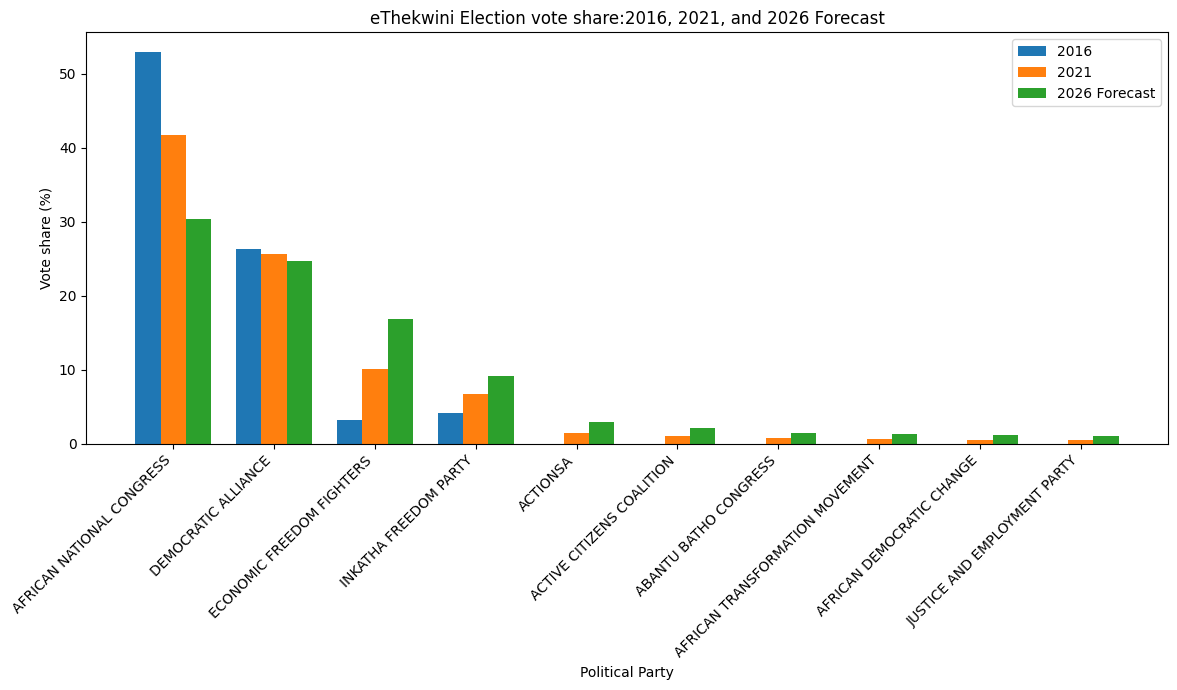

In [103]:

import matplotlib.pyplot as plt

top_10=forecast_2026.head(10).copy()

plt.figure(figsize=(12, 7))
x = range (len(top_10))

plt.bar(
    [i - 0.25 for i in x],
    top_10["share_2016"],
    width=0.25,
    label="2016"
)
plt.bar(
    x,
    top_10["share_2021"],
    width=0.25,
    label="2021"
)
plt.bar(
    [i + 0.25 for i in x],
    top_10["forecast_2026_final"],
    width=0.25,
    label="2026 Forecast"
)
plt.xticks(
    x,
    top_10["partyname"],
    rotation=45,
    ha="right"
)
plt.ylabel("Vote share (%)")
plt.xlabel("Political Party")
plt.title("eThekwini Election vote share:2016, 2021, and 2026 Forecast")


plt.legend()
plt.tight_layout()
plt.show()

Forecasted 2026 vote share

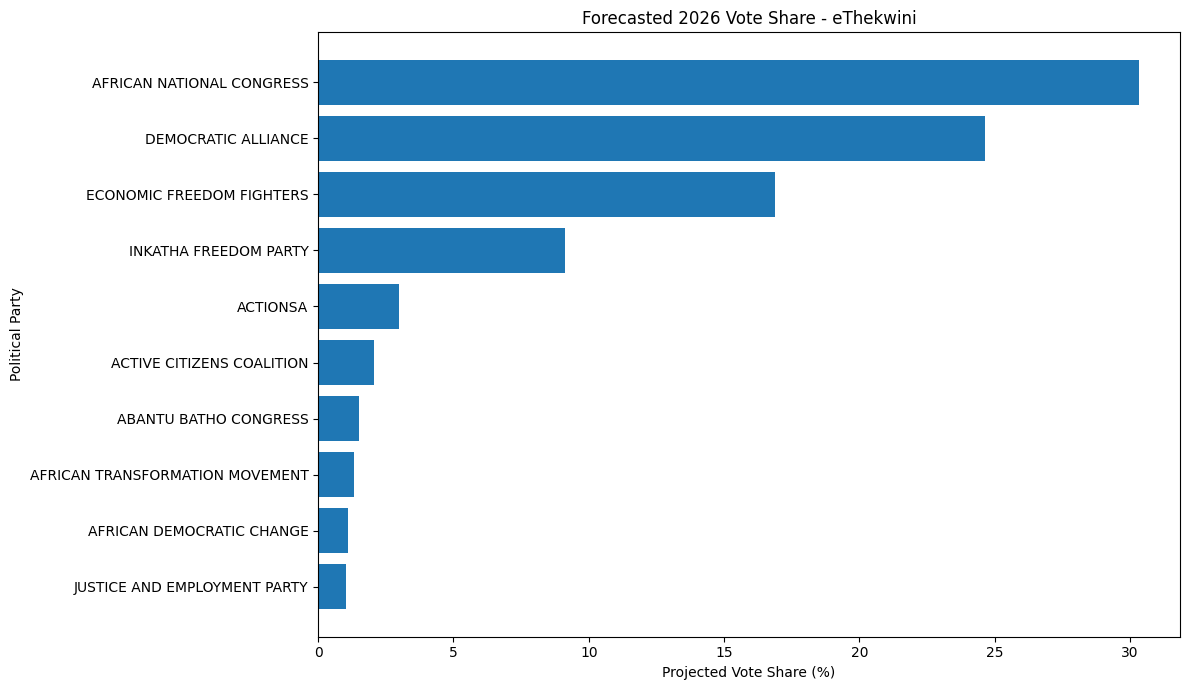

In [104]:
top_10 = forecast_2026.head(10).copy()
plt.figure(figsize=(12, 7))
plt.barh(
    top_10["partyname"],
    top_10["forecast_2026_final"]

)
plt.xlabel("Projected Vote Share (%)")
plt.ylabel("Political Party")
plt.title("Forecasted 2026 Vote Share - eThekwini")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2026 vote share composition


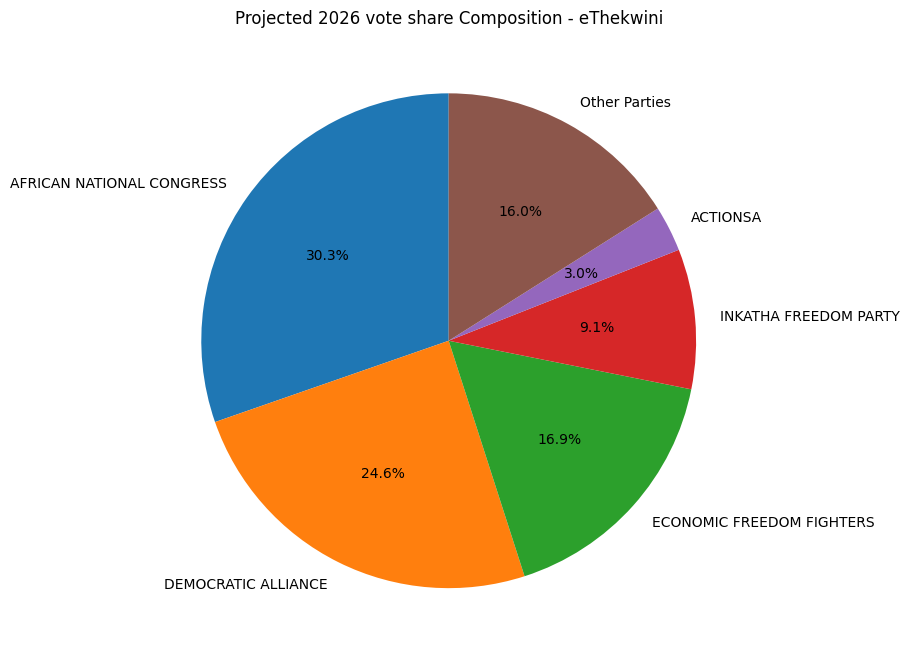

In [106]:
top_5 = forecast_2026.head(5).copy()
other_votes = forecast_2026.iloc[5:]["forecast_2026_final"].sum()

pie_data=list(top_5["forecast_2026_final"])+[other_votes]

pie_labels=list(top_5["partyname"])+ ["Other Parties"]
plt.figure(figsize=(9, 9))
plt.pie(
    pie_data,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Projected 2026 vote share Composition - eThekwini")
plt.tight_layout()
plt.show()

Vote share trend

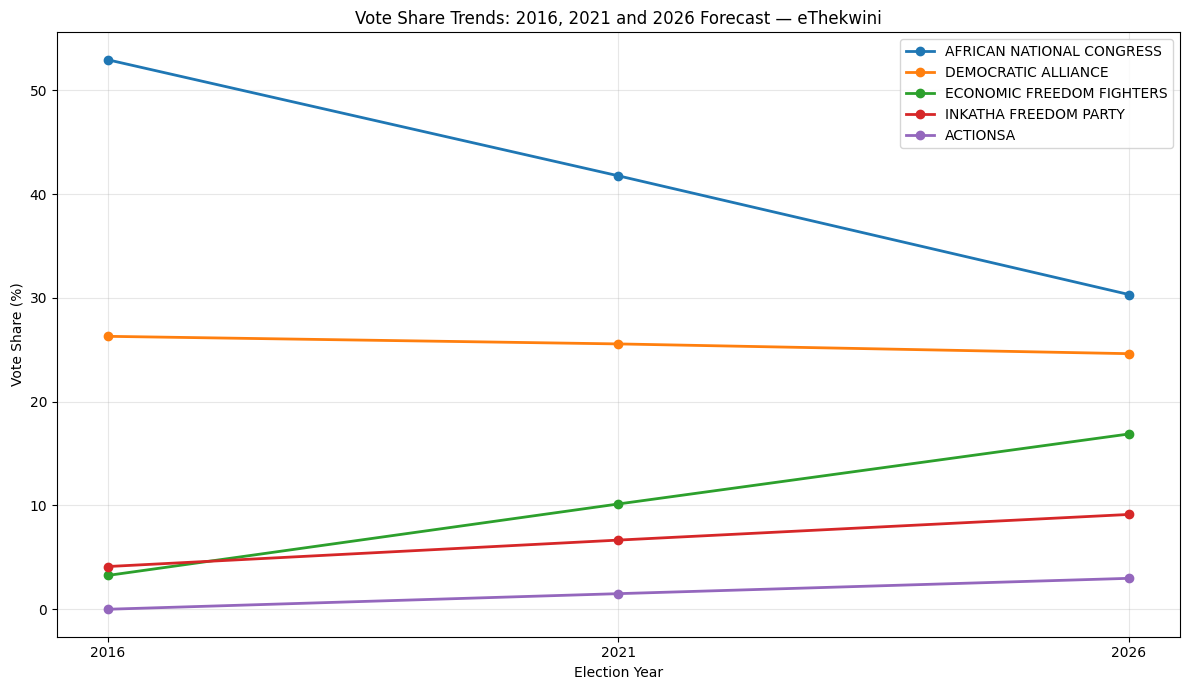

In [107]:

top_5 = forecast_2026.head(5).copy()

years = [2016, 2021, 2026]

plt.figure(figsize=(12, 7))

for _, row in top_5.iterrows():
    values = [
        row["share_2016"],
        row["share_2021"],
        row["forecast_2026_final"]
    ]

    plt.plot(
        years,
        values,
        marker="o",
        linewidth=2,
        label=row["partyname"]
    )

plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")
plt.title(
    "Vote Share Trends: 2016, 2021 and 2026 Forecast — eThekwini"
)

plt.xticks(years)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2026 Forecast with Uncertainty Range

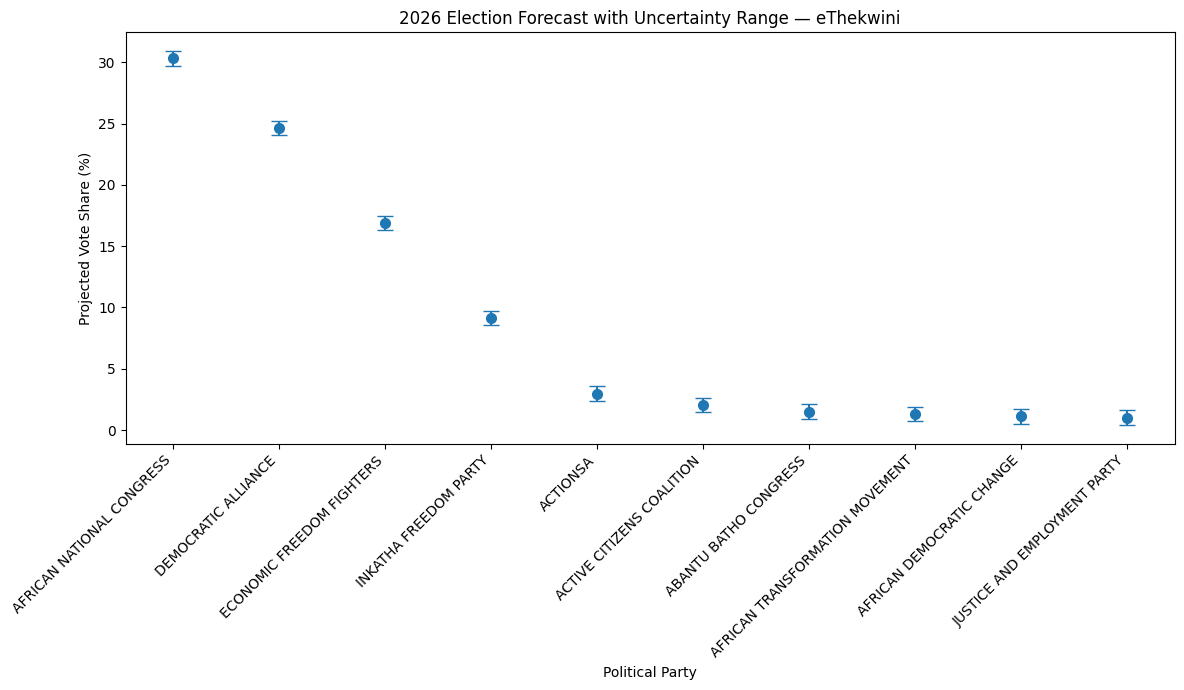

In [108]:

top_10 = forecast_2026.head(10).copy()

plt.figure(figsize=(12, 7))

x = range(len(top_10))

plt.errorbar(
    x,
    top_10["forecast_2026_final"],
    yerr=[
        top_10["forecast_2026_final"] - top_10["lower_bound"],
        top_10["upper_bound"] - top_10["forecast_2026_final"]
    ],
    fmt="o",
    capsize=6,
    markersize=7
)

plt.xticks(
    x,
    top_10["partyname"],
    rotation=45,
    ha="right"
)

plt.xlabel("Political Party")
plt.ylabel("Projected Vote Share (%)")

plt.title(
    "2026 Election Forecast with Uncertainty Range — eThekwini"
)

plt.tight_layout()
plt.show()

Final Forecast results table

In [111]:
final_results=forecast_2026[
    [
        "partyname",
        "share_2021",
        "forecast_2026_final",
        "projected_votes_2026",
        "lower_bound",
        "upper_bound"
    ]
].copy()
final_results = final_results.head(10)

final_results.columns =[
    " Party",
    "2021 Vote Share (%))",
    "2026 Forecast (%)",
    "Projected 2026 Votes",
    "Lower Bound (%)",
    "Upper Bound (%)"
]
final_results

,Party,2021 Vote Share (%)),2026 Forecast (%),Projected 2026 Votes,Lower Bound (%),Upper Bound (%)
13,AFRICAN NATIONAL CONGRESS,41.769425,30.330579,235370,29.734908,30.926251
24,DEMOCRATIC ALLIANCE,25.570769,24.630818,191139,24.035147,25.226489
27,ECONOMIC FREEDOM FIGHTERS,10.147742,16.892302,131087,16.296631,17.487973
35,INKATHA FREEDOM PARTY,6.665464,9.136735,70902,8.541064,9.732406
2,ACTIONSA,1.502935,2.980694,23131,2.385023,3.576365
3,ACTIVE CITIZENS COALITION,1.034129,2.050936,15916,1.455265,2.646607
0,ABANTU BATHO CONGRESS,0.755913,1.499164,11634,0.903493,2.094835
17,AFRICAN TRANSFORMATION MOVEMENT,0.661199,1.311321,10176,0.715650,1.906992
8,AFRICAN DEMOCRATIC CHANGE,0.557721,1.106100,8584,0.510429,1.701771
37,JUSTICE AND EMPLOYMENT PARTY,0.510171,1.011795,7852,0.416124,1.607466


**FINDINGS AND CONCLUSION**

The analysis used 2016 and 2021 results from e Thewini district shows that the ANC remained the largest party although its vote share declined from 52.95in 2016 to 41.77 in 2021. The EFF and IFP votes shares increased during the same period

the Forecasting Model projects the following for 2026 that:

ANC: 30.33%

DA:24.63%

EFF:16.89%

IFP:9.14%

The models projects that the ANC will receive the largest aggregate vote total in eThekwini in 2026 nov elections


Conclusion: Based on historical voting trends, the model projects that the ANC will receive the largest vote total in eThekwini in Nov 2026 Local Government Elections

**STREAMLIT**

https://d6jmkvrxpnem2ov3vj9byj.streamlit.app/